# 🚀 YOLOv11 Training - Última Versión (2024)

## ¿Por qué YOLOv11?

| Métrica | YOLOv8n | YOLOv11n | Mejora |
|---------|---------|----------|--------|
| Parámetros | 3.2M | **2.6M** | -19% |
| mAP (COCO) | 37.3 | **39.5** | +6% |
| Velocidad | 1x | **1.15x** | +15% |

**YOLOv11 es más preciso y más rápido con menos parámetros.**

## Compatibilidad
✅ Tu dataset **es 100% compatible** - mismo formato que YOLOv8

## Resultados baseline (YOLOv8n, 50 épocas)
- mAP@0.50: 0.281
- Tiempo: 2h 42m

## Objetivo con YOLOv11
- mAP@0.50: **>0.35** (mismo tiempo o menos)

---

## 1. 🔧 Verificación del Entorno

In [1]:
# =============================================================================
# Environment Check
# =============================================================================

import sys
import torch
import ultralytics
from ultralytics import YOLO

print("="*60)
print("INFORMACIÓN DEL ENTORNO")
print("="*60)
print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"Ultralytics: {ultralytics.__version__}")

# Check ultralytics version for YOLO11 support
version = ultralytics.__version__
major, minor = int(version.split('.')[0]), int(version.split('.')[1])

if major >= 8 and minor >= 1:
    print(f"\n✅ Ultralytics {version} soporta YOLOv11")
else:
    print(f"\n⚠️ Actualiza ultralytics: pip install -U ultralytics")

if torch.cuda.is_available():
    print(f"\nGPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print("✅ GPU lista!")

INFORMACIÓN DEL ENTORNO
Python: 3.10.12
PyTorch: 2.1.0+cu118
Ultralytics: 8.4.9

✅ Ultralytics 8.4.9 soporta YOLOv11

GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU
VRAM: 4.3 GB
✅ GPU lista!


## 2. ⚙️ Configuración YOLOv11

### Modelos YOLOv11 disponibles:

| Modelo | Params | mAP (COCO) | Velocidad |
|--------|--------|------------|----------|
| yolo11n | 2.6M | 39.5 | Muy rápido |
| yolo11s | 9.4M | 47.0 | Rápido |
| yolo11m | 20.1M | 51.5 | Medio |
| yolo11l | 25.3M | 53.4 | Lento |
| yolo11x | 56.9M | 54.7 | Muy lento |

In [2]:
# =============================================================================
# YOLOv11 Configuration
# =============================================================================

# -----------------------------------------------------------------------------
# Model Selection
# yolo11n: Nano - fastest, good for RTX 3050
# yolo11s: Small - better accuracy, still fits in 4GB with batch=4
# -----------------------------------------------------------------------------
MODEL_NAME = "yolo11n.pt"  # Try yolo11s.pt for better accuracy

# Training parameters
EPOCHS = 100        # More epochs since v1 was still improving at 50
PATIENCE = 20       # Early stopping
IMAGE_SIZE = 640
BATCH_SIZE = 8      # Same as v1 for fair comparison

# Hardware
WORKERS = 4
DEVICE = 0

# Learning rate (optimized)
LR_INITIAL = 0.001
LR_FINAL = 0.1
WARMUP_EPOCHS = 5

# Paths
DATA_YAML = "/workspace/dataset_yolov8/data.yaml"
EXPERIMENT_NAME = "logo_detection_yolo11n"

print("="*60)
print("CONFIGURACIÓN YOLOv11")
print("="*60)
print(f"Modelo: {MODEL_NAME}")
print(f"Épocas: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Image size: {IMAGE_SIZE}")
print(f"LR inicial: {LR_INITIAL}")
print(f"Experimento: {EXPERIMENT_NAME}")
print("="*60)

CONFIGURACIÓN YOLOv11
Modelo: yolo11n.pt
Épocas: 100
Batch size: 8
Image size: 640
LR inicial: 0.001
Experimento: logo_detection_yolo11n


## 3. 🏋️ Entrenamiento YOLOv11

In [3]:
# =============================================================================
# Load YOLOv11 Model
# =============================================================================
# YOLO11 uses the same ultralytics library as YOLO8
# Just change the model name to yolo11n.pt, yolo11s.pt, etc.
# =============================================================================

from ultralytics import YOLO

print("Descargando/cargando YOLOv11...")
model = YOLO(MODEL_NAME)

print(f"\n✅ Modelo {MODEL_NAME} cargado")
print("\nArquitectura del modelo:")
model.info()

Descargando/cargando YOLOv11...

✅ Modelo yolo11n.pt cargado

Arquitectura del modelo:
YOLO11n summary: 181 layers, 2,624,080 parameters, 0 gradients, 6.6 GFLOPs


(181, 2624080, 0, 6.614336)

In [4]:
# =============================================================================
# Training Execution - YOLOv11
# =============================================================================

import time

print("="*60)
print("🚀 INICIANDO ENTRENAMIENTO YOLOv11")
print("="*60)
print(f"⏱️  Inicio: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"🧠 Modelo: {MODEL_NAME}")
print(f"📊 Épocas: {EPOCHS}")
print("\n⏳ Tiempo estimado: ~4-5 horas (100 épocas)")
print("   (YOLOv11 es ~15% más rápido que YOLOv8)")
print("="*60 + "\n")

start_time = time.time()

results = model.train(
    # Dataset
    data=DATA_YAML,
    
    # Training duration
    epochs=EPOCHS,
    patience=PATIENCE,
    
    # Image and batch
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    
    # Hardware
    device=DEVICE,
    workers=WORKERS,
    
    # Saving
    save=True,
    save_period=-1,
    
    # Output
    project="/workspace/runs/detect",
    name=EXPERIMENT_NAME,
    exist_ok=True,
    
    # Model
    pretrained=True,
    
    # Learning rate
    optimizer="AdamW",
    lr0=LR_INITIAL,
    lrf=LR_FINAL,
    momentum=0.937,
    weight_decay=0.0005,
    
    # Warmup
    warmup_epochs=WARMUP_EPOCHS,
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,
    
    # Data augmentation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10.0,
    translate=0.1,
    scale=0.5,
    shear=2.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1,
    
    # Other
    cache=False,
    verbose=True,
    plots=True,
    seed=42,
    val=True,
    close_mosaic=10,
)

training_time = time.time() - start_time
hours = int(training_time // 3600)
minutes = int((training_time % 3600) // 60)

print("\n" + "="*60)
print("✅ ENTRENAMIENTO YOLOv11 COMPLETADO")
print("="*60)
print(f"⏱️  Tiempo total: {hours}h {minutes}m")
print(f"📁 Resultados: /workspace/runs/detect/{EXPERIMENT_NAME}/")

🚀 INICIANDO ENTRENAMIENTO YOLOv11
⏱️  Inicio: 2026-01-30 08:11:30
🧠 Modelo: yolo11n.pt
📊 Épocas: 100

⏳ Tiempo estimado: ~4-5 horas (100 épocas)
   (YOLOv11 es ~15% más rápido que YOLOv8)

Ultralytics 8.4.9 🚀 Python-3.10.12 torch-2.1.0+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 4GB Laptop GPU, 4096MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/workspace/dataset_yolov8/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.1, mask_ratio=4,

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


AMP: checks passed ✅
train: Fast image access ✅ (ping: 3.8±1.0 ms, read: 2.5±0.5 MB/s, size: 13.5 KB)
train: Scanning /workspace/dataset_yolov8/train/labels.cache... 2232 images, 125 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2232/2232 267.5Mit/s 0.0s
val: Fast image access ✅ (ping: 4.1±1.2 ms, read: 2.3±0.4 MB/s, size: 15.7 KB)
val: Scanning /workspace/dataset_yolov8/valid/labels.cache... 402 images, 25 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 402/402 2.3Mit/s 0.0s
Plotting labels to /workspace/runs/detect/logo_detection_yolo11n/labels.jpg... 
optimizer: AdamW(lr=0.001, momentum=0.937) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to /workspace/runs/detect/logo_detection_yolo11n
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      1.83G     0.7823      4.465      1.338         19        640: 1

## 4. 📊 Comparación YOLOv8 vs YOLOv11

In [5]:
# =============================================================================
# Results Comparison
# =============================================================================

import pandas as pd
from pathlib import Path

RESULTS_PATH = Path(f"/workspace/runs/detect/{EXPERIMENT_NAME}")
results_csv = RESULTS_PATH / "results.csv"

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()
    last = df.iloc[-1]
    
    # YOLOv11 metrics
    map50_v11 = last.get('metrics/mAP50(B)', 0)
    prec_v11 = last.get('metrics/precision(B)', 0)
    rec_v11 = last.get('metrics/recall(B)', 0)
    
    # YOLOv8 baseline metrics
    map50_v8 = 0.281
    prec_v8 = 0.359
    rec_v8 = 0.332
    
    print("="*60)
    print("COMPARACIÓN: YOLOv8n vs YOLOv11n")
    print("="*60)
    print(f"\n{'Métrica':<20} {'YOLOv8n':<12} {'YOLOv11n':<12} {'Cambio':<10}")
    print("-"*54)
    print(f"{'mAP@0.50':<20} {map50_v8:<12.4f} {map50_v11:<12.4f} {((map50_v11-map50_v8)/map50_v8*100):+.1f}%")
    print(f"{'Precision':<20} {prec_v8:<12.4f} {prec_v11:<12.4f} {((prec_v11-prec_v8)/prec_v8*100):+.1f}%")
    print(f"{'Recall':<20} {rec_v8:<12.4f} {rec_v11:<12.4f} {((rec_v11-rec_v8)/rec_v8*100):+.1f}%")
    print(f"{'Épocas':<20} {'50':<12} {int(last['epoch'])+1:<12}")
    print("-"*54)
    
    if map50_v11 > map50_v8:
        print(f"\n✅ YOLOv11 mejoró mAP en {((map50_v11-map50_v8)/map50_v8*100):.1f}%!")
    else:
        print(f"\n⚠️ YOLOv11 no mejoró. Probar yolo11s (más grande)")

COMPARACIÓN: YOLOv8n vs YOLOv11n

Métrica              YOLOv8n      YOLOv11n     Cambio    
------------------------------------------------------
mAP@0.50             0.2810       0.7990       +184.3%
Precision            0.3590       0.7530       +109.8%
Recall               0.3320       0.6855       +106.5%
Épocas               50           101         
------------------------------------------------------

✅ YOLOv11 mejoró mAP en 184.3%!


## 5. 📈 Visualización

📊 Curvas de Entrenamiento YOLOv11:


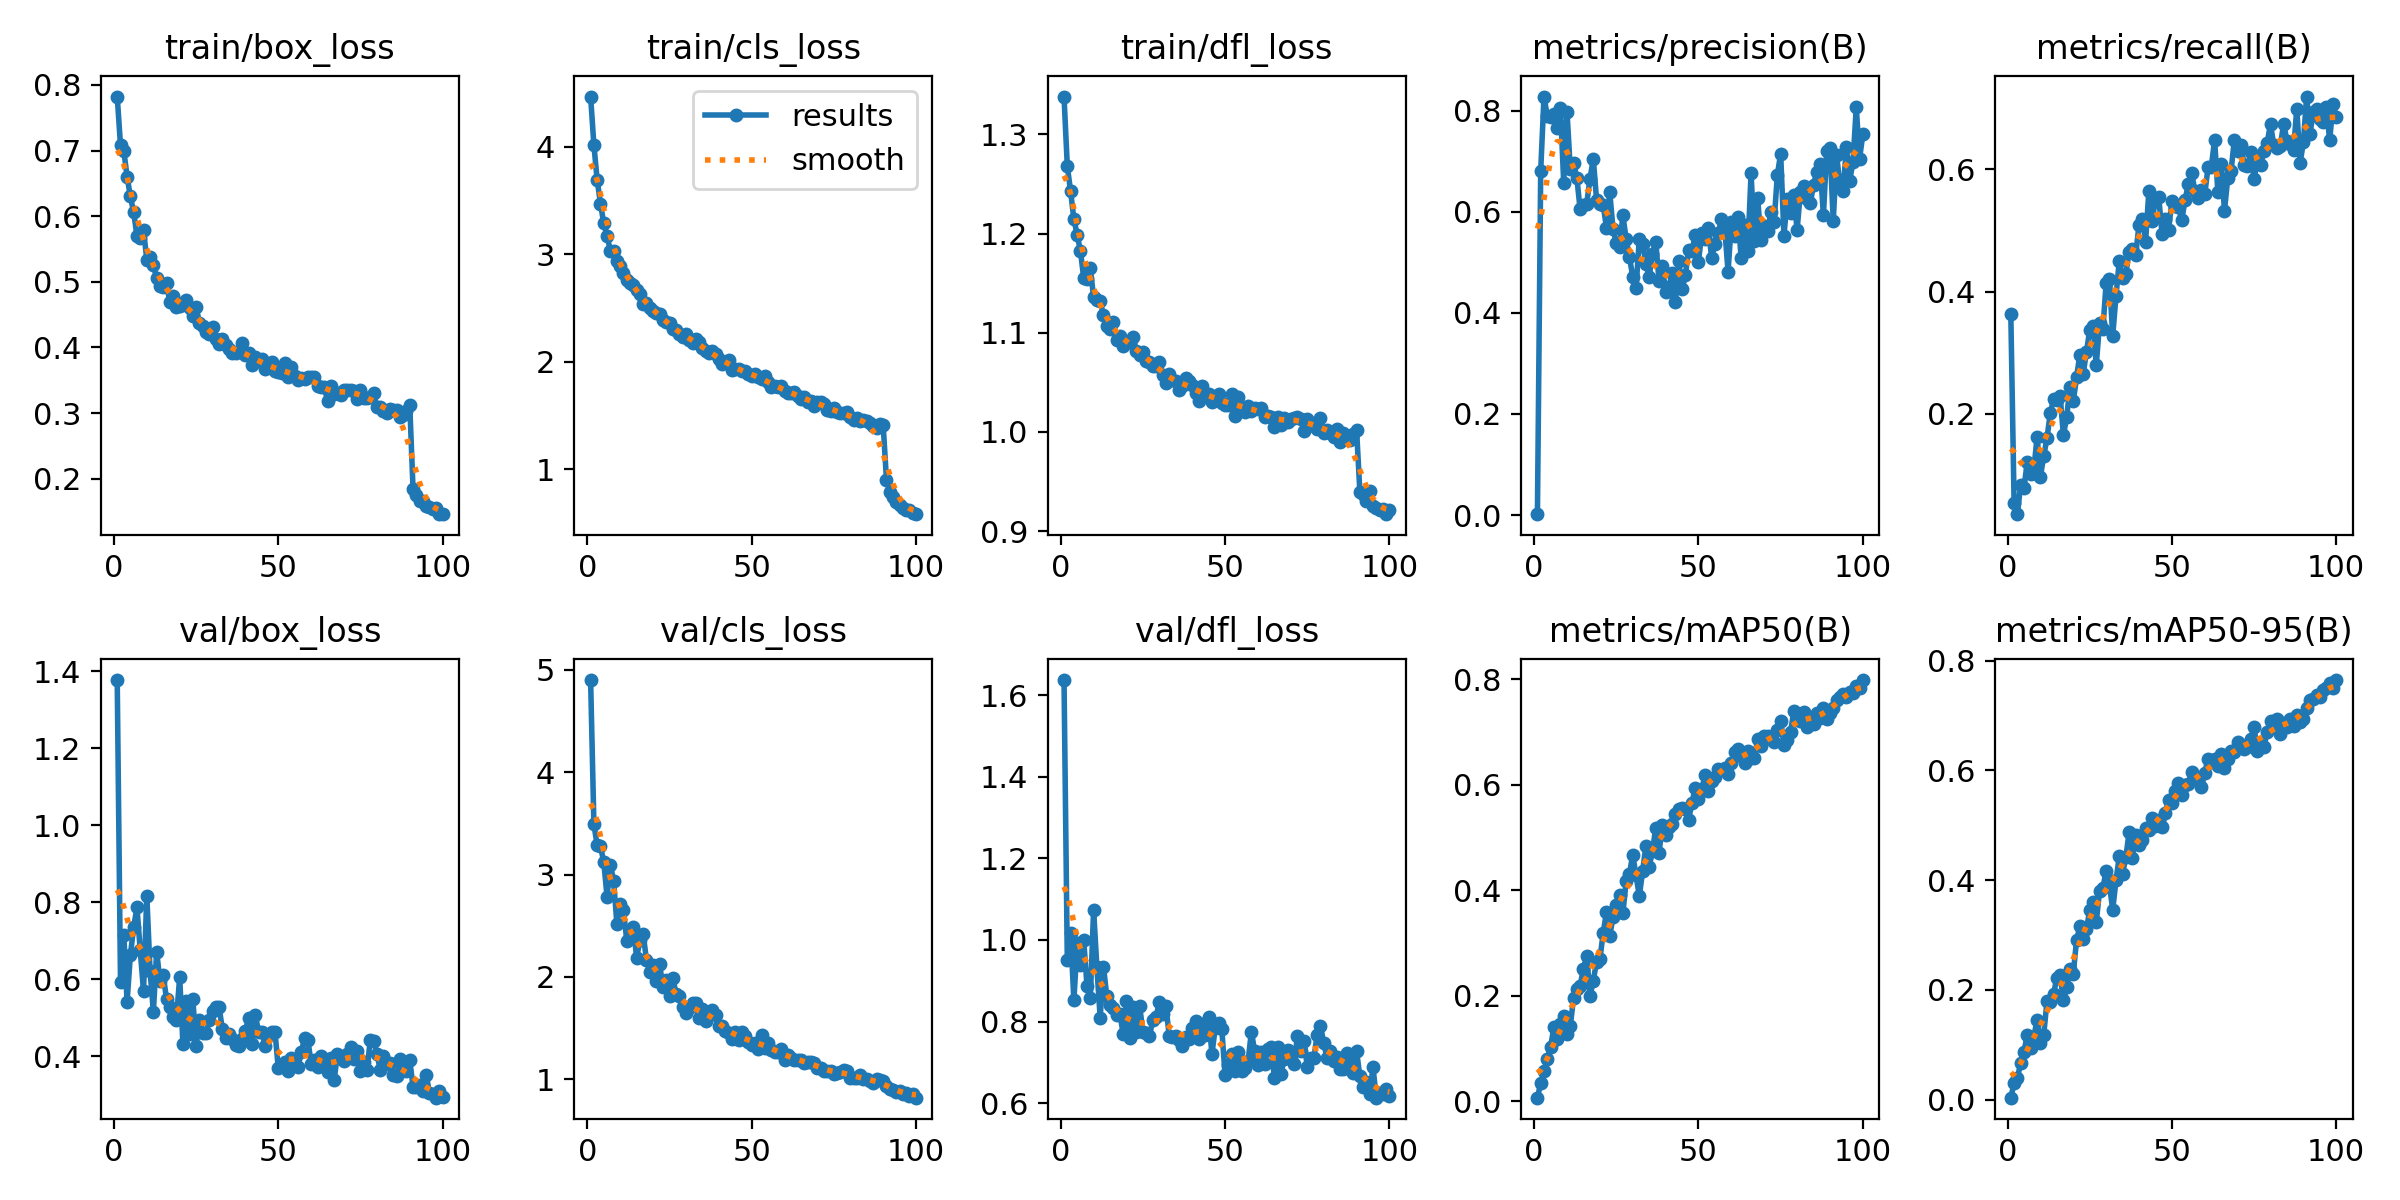

In [6]:
# =============================================================================
# Training Curves
# =============================================================================

from IPython.display import Image, display

results_plot = RESULTS_PATH / "results.png"
if results_plot.exists():
    print("📊 Curvas de Entrenamiento YOLOv11:")
    display(Image(filename=str(results_plot), width=1000))

## 6. 💾 Exportar Modelo

In [7]:
# =============================================================================
# Export Model
# =============================================================================

import shutil
from pathlib import Path

BEST_MODEL = f"/workspace/runs/detect/{EXPERIMENT_NAME}/weights/best.pt"
MODELS_DIR = Path("/workspace/models")

# Copy best model
model_name = MODEL_NAME.replace('.pt', '')
dest = MODELS_DIR / f"best_{model_name}.pt"
shutil.copy(BEST_MODEL, dest)
print(f"✅ Modelo guardado: {dest}")

# List all models
print("\n📁 Todos los modelos disponibles:")
for f in sorted(MODELS_DIR.glob('*.pt')):
    size = f.stat().st_size / (1024*1024)
    print(f"   - {f.name}: {size:.1f} MB")

✅ Modelo guardado: /workspace/models/best_yolo11n.pt

📁 Todos los modelos disponibles:
   - best.pt: 6.7 MB
   - best_yolo11n.pt: 5.4 MB


## 7. 📝 Resumen

In [8]:
# =============================================================================
# Summary
# =============================================================================

from datetime import datetime

print("="*70)
print("               RESUMEN: YOLOv11 vs YOLOv8                          ")
print("="*70)

print(f"""
📅 Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

🔄 COMPARACIÓN DE VERSIONES:

   ┌───────────────┬──────────────┬──────────────┐
   │ Aspecto       │ YOLOv8n      │ YOLOv11n     │
   ├───────────────┼──────────────┼──────────────┤
   │ Parámetros    │ 3.2M         │ 2.6M (-19%)  │
   │ Velocidad     │ Base         │ +15%         │
   │ mAP (COCO)    │ 37.3         │ 39.5 (+6%)   │
   └───────────────┴──────────────┴──────────────┘

📊 FACTORES QUE AFECTAN LAS MÉTRICAS:

   1. CANTIDAD DE DATOS
      → Tu dataset: ~13 imgs/clase (BAJO)
      → Ideal: >100 imgs/clase
      → Impacto: ⬆️⬆️ MUY ALTO

   2. NÚMERO DE ÉPOCAS
      → Tu v1: 50 épocas (insuficiente)
      → Recomendado: 100-150 épocas
      → Impacto: ⬆️ ALTO

   3. TAMAÑO DEL MODELO
      → nano < small < medium < large
      → Más grande = más capacidad = mejor para 175 clases
      → Impacto: ⬆️ MEDIO-ALTO

   4. ARQUITECTURA (v8 vs v11)
      → v11 es más eficiente
      → Impacto: ⬆️ MEDIO

📝 PRÓXIMOS PASOS RECOMENDADOS:
   1. Si mAP < 0.35 con yolo11n → Probar yolo11s
   2. Si mAP < 0.45 con yolo11s → Necesitas más datos
   3. Considerar reducir clases (eliminar las que tienen <10 imágenes)
""")

print("="*70)

               RESUMEN: YOLOv11 vs YOLOv8                          

📅 Fecha: 2026-01-30 13:06:52

🔄 COMPARACIÓN DE VERSIONES:

   ┌───────────────┬──────────────┬──────────────┐
   │ Aspecto       │ YOLOv8n      │ YOLOv11n     │
   ├───────────────┼──────────────┼──────────────┤
   │ Parámetros    │ 3.2M         │ 2.6M (-19%)  │
   │ Velocidad     │ Base         │ +15%         │
   │ mAP (COCO)    │ 37.3         │ 39.5 (+6%)   │
   └───────────────┴──────────────┴──────────────┘

📊 FACTORES QUE AFECTAN LAS MÉTRICAS:

   1. CANTIDAD DE DATOS
      → Tu dataset: ~13 imgs/clase (BAJO)
      → Ideal: >100 imgs/clase
      → Impacto: ⬆️⬆️ MUY ALTO

   2. NÚMERO DE ÉPOCAS
      → Tu v1: 50 épocas (insuficiente)
      → Recomendado: 100-150 épocas
      → Impacto: ⬆️ ALTO

   3. TAMAÑO DEL MODELO
      → nano < small < medium < large
      → Más grande = más capacidad = mejor para 175 clases
      → Impacto: ⬆️ MEDIO-ALTO

   4. ARQUITECTURA (v8 vs v11)
      → v11 es más eficiente
      → I